# **TRABAJO PRACTICO 6 - SANTIAGO VOLIO**

# **EJERCICIO 1**

Función: f(x) = x^2 - 6x en [3, 6]
n = 10 rectángulos
Suma de Riemann ≈ -19.305000
Integral exacta = -18 ≈ -18.000000000000000000000000000000000000000000000000000000000000000000
Error (aprox - exacta) = -1.305000


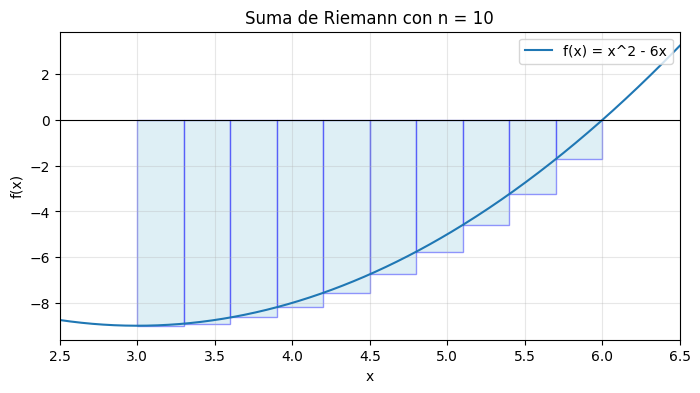

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, integrate

x = symbols('x')
f_sym = x**2 - 6*x
f = lambdify(x, f_sym, 'numpy')

a, b = 3, 6

I_exact = integrate(f_sym, (x, a, b))
I_exact_float = float(I_exact)

n = 10

delta_x = (b - a) / n
x_rect = np.linspace(a, b - delta_x, n)
alturas = f(x_rect)
suma_riemann = np.sum(alturas * delta_x)

print(f"Función: f(x) = x^2 - 6x en [{a}, {b}]")
print(f"n = {n} rectángulos")
print(f"Suma de Riemann ≈ {suma_riemann:.6f}")
print(f"Integral exacta = {I_exact} ≈ {I_exact_float:.66f}")
print(f"Error (aprox - exacta) = {suma_riemann - I_exact_float:.6f}")

x_plot = np.linspace(a - 0.5, b + 0.5, 400)
y_plot = f(x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, y_plot, label="f(x) = x^2 - 6x")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

for x_i, h in zip(x_rect, alturas):
    plt.bar(x_i, h, width=delta_x, align="edge",
            alpha=0.4, edgecolor="blue", color="lightblue")

plt.xlim(a - 0.5, b + 0.5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Suma de Riemann con n = {n}")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()


# **Conclusión del Ejercicio 1**

Al cambiar en el código la cantidad de rectángulos \(n\) y ejecutar la suma de Riemann, se observa que:

- Cuando **aumenta** \(n\), cada rectángulo se vuelve más **angosto** (\(\Delta x\) disminuye).
- Los rectángulos se ajustan mejor a la gráfica de la función \(f(x) = x^2 - 6x\) en el intervalo \([3,6]\).
- El valor numérico de la suma de Riemann se va **acercando** al valor de la integral definida exacta  
  \[
  \int_{3}^{6} (x^2 - 6x)\,dx = -\frac{27}{2} \approx -13.5.
  \]

**Explicación conceptual**

La suma de Riemann es una **aproximación** del área firmada bajo la curva.  
Al aumentar la cantidad de rectángulos \(n\):

- El error entre la suma de Riemann y la integral definida se hace cada vez **más pequeño**.
- En el límite, cuando \(n \to \infty\), la suma de Riemann **coincide** con la integral definida.

Por eso, mientras más rectángulos usemos, mejor aproximamos el valor real de la integral.


# **EJERCICIO 2**

In [ ]:
import numpy as np

tiempos = np.array([0, 10, 15, 20, 32, 59, 62])
velocidades = np.array([0, 56, 97, 136, 226, 404, 440])

delta_t = np.diff(tiempos)
v_prom = velocidades[:-1]

altura = np.sum(v_prom * delta_t)
altura


np.int64(9711)



Los datos de velocidad están dados en tiempos que no son equidistantes. Para aproximar la distancia recorrida (altura), usando la suma de Riemann:

por lo tanto, se usan los valores de velocidad del instante inicial de cada intervalo.

Esto funciona porque la distancia recorrida es la integral de la velocidad, y una suma de Riemann aproxima esa integral incluso cuando los intervalos no son uniformes.

Al ejecutar el código, se obtiene la altura aproximada recorrida por el transbordador en los primeros 62 segundos de vuelo.


# **EJERCICIO 3**

Puntos derechos: [0.5 1.  1.5 2.  2.5 3. ]
Valores f(x_i): [-3.75 -3.   -1.75  0.    2.25  5.  ]
Suma de Riemann S_6 = -0.625


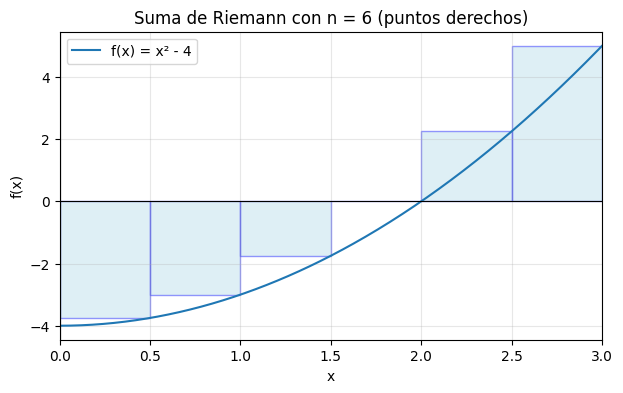

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 - 4

a, b = 0, 3
n = 6

delta_x = (b - a) / n
x_right = np.array([a + i*delta_x for i in range(1, n+1)])  # puntos derechos

S6 = np.sum(f(x_right) * delta_x)

print("Puntos derechos:", x_right)
print("Valores f(x_i):", f(x_right))
print("Suma de Riemann S_6 =", S6)

x_plot = np.linspace(a, b, 400)
y_plot = f(x_plot)

plt.figure(figsize=(7,4))
plt.plot(x_plot, y_plot, label="f(x) = x² - 4")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

for x_i in x_right:
    altura = f(x_i)
    x_rect = x_i - delta_x
    plt.bar(x_rect, altura, width=delta_x, align="edge",
            alpha=0.4, edgecolor="blue", color="lightblue")

plt.xlim(a, b)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Suma de Riemann con n = {n} (puntos derechos)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **EJERCICIO 4**

AUC exacto: 0.48
Interpretación: Modelo peor que azar
AUC por suma de Riemann (n = 5): 0.62
Error de aproximación: 0.14


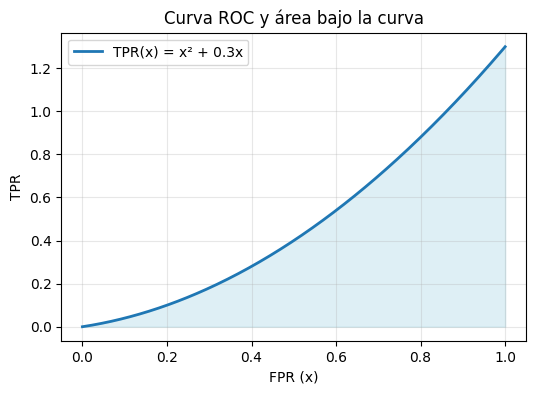

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.Symbol('x')
TPR = x**2 + 0.3*x

# Calcular el Área Bajo la Curva (AUC) exacta usando integración simbólica

AUC_exact = sp.integrate(TPR, (x, 0, 1))
AUC_exact_float = float(AUC_exact)

# Imprime el valor exacto del AUC, redondeado a 2 decimales
print(f"AUC exacto: {AUC_exact_float:.2f}")

# Valor del AUC basándose en umbrales comunes para el rendimiento del modelo
if AUC_exact_float >= 0.9:
    interpretacion = "Modelo excelente"
elif AUC_exact_float >= 0.8:
    interpretacion = "Modelo muy bueno"
elif AUC_exact_float >= 0.7:
    interpretacion = "Modelo aceptable"
elif AUC_exact_float >= 0.5:
    interpretacion = "Modelo apenas mejor que azar"
else:
    interpretacion = "Modelo peor que azar"

# Imprime la interpretación del rendimiento del modelo
print("Interpretación:", interpretacion)


n = 5
a, b = 0, 1
delta_x = (b - a) / n

# Calcular los puntos finales derechos de cada subintervalo

x_right = np.array([a + i*delta_x for i in range(1, n+1)])
TPR_num = sp.lambdify(x, TPR, "numpy")
AUC_riemann = np.sum(TPR_num(x_right) * delta_x)
print(f"AUC por suma de Riemann (n = 5): {AUC_riemann:.2f}")
print(f"Error de aproximación: {(AUC_riemann - AUC_exact_float):.2f}")


x_plot = np.linspace(0, 1, 400)
TPR_plot = TPR_num(x_plot)
plt.figure(figsize=(6,4))
plt.plot(x_plot, TPR_plot, label="TPR(x) = x² + 0.3x", linewidth=2)
plt.fill_between(x_plot, TPR_plot, color="lightblue", alpha=0.4)
plt.title("Curva ROC y área bajo la curva")
plt.xlabel("FPR (x)")
plt.ylabel("TPR")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Explicación del problema del área bajo la curva y la suma de Riemann

El área bajo la curva ROC es una medida que describe qué tan bien un modelo de clasificación logra separar dos clases. Se obtiene evaluando la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos a lo largo de todo el rango posible de decisiones del modelo. Mientras el área sea mayor, mejor es la capacidad del modelo para distinguir correctamente entre casos positivos y negativos.

Para calcular esta área se utiliza una integral definida, porque la curva es continua en el intervalo evaluado. La integral permite sumar la contribución de cada punto infinitesimal de la curva, obteniendo el área total bajo ella. Un valor cercano a cero indica un mal desempeño, un valor intermedio indica un comportamiento apenas mejor que el azar, y un valor cercano a uno sugiere un modelo altamente confiable.

Cuando no se desea o no se puede usar la integral exacta, se puede aproximar el área mediante una suma de Riemann. Esto consiste en dividir el intervalo en varias partes y sumar áreas de rectángulos que se apoyan en la curva. Cuantos más rectángulos se utilicen, más se parecerá la aproximación al valor real.

La suma de Riemann con pocos subintervalos ofrece una estimación razonable pero no perfecta. A medida que se incrementa la cantidad de subintervalos, la aproximación se vuelve más precisa, ya que los rectángulos representan mejor la forma curva de la función. En este caso, incluso con un número reducido de subintervalos, el resultado es cercano al área exacta y permite verificar la calidad del modelo.
